#Modelo con autoaprendizaje

In [ ]:
import numpy as np
import pandas as pd
import os
import joblib
from datetime import datetime
import gradio as gr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# -----------------------
# CONFIGURACIÓN DE RUTAS
# -----------------------
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/hackathon/'
DATASET_PRINCIPAL = BASE_PATH + 'dataset_modelado_sentimiento.csv'
DATASET_FEEDBACK = BASE_PATH + 'consultas_recolectadas.csv'
MODEL_PATH = BASE_PATH + 'modelo_final.pkl'
VECT_PATH = BASE_PATH + 'vectorizador_final.pkl'

# --------------------------------------------
# CARGA Y UNIFICACIÓN DE DATOS
# --------------------------------------------
def cargar_datos_unificados():
    df_base = pd.read_csv(DATASET_PRINCIPAL)
    if 'Frase' in df_base.columns:
        df_base.rename(columns={'Frase': 'clean_text', 'Etiqueta': 'y'}, inplace=True)

    if os.path.exists(DATASET_FEEDBACK):
        df_feedback = pd.read_csv(DATASET_FEEDBACK)
        df_feedback_clean = df_feedback[['clean_text', 'y']]
        df_unificado = pd.concat([df_base, df_feedback_clean], ignore_index=True)
        print(f"✅ Entrenando con {len(df_base)} base + {len(df_feedback)} correcciones nuevas.")
    else:
        df_unificado = df_base

    df_unificado.dropna(subset=['clean_text', 'y'], inplace=True)
    df_unificado['y'] = df_unificado['y'].astype(int)
    return df_unificado

df = cargar_datos_unificados()

# -----------------------------------
# ENTRENAMIENTO OPTIMIZADO
# -----------------------------------
X = df['clean_text'].fillna('')
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

stop_words_es = [
    "el", "la", "los", "las", "un", "una", "unos", "unas", "de", "en", "con", "para", "por",
    "sobre", "entre", "y", "o", "que", "porque", "como", "cuando", "donde", "a", "al", "del",
    "es", "son", "fue", "eran", "ser", "estar", "tener", "hay", "esta", "está", "sido", "ir", "va",
    "yo", "tu", "él", "ella", "nosotros", "ustedes", "ellos", "mi", "mis", "su", "sus", "me", "se", "le",
    "sevilla", "hotel", "hostal", "alojamiento", "estancia", "noche", "noches",
    "habitación", "habitacion", "camas", "cama", "baño", "desayuno", "ubicación",
    "situación", "precio", "check", "in", "out", "personal", "cliente", "recepción"
]

vectorizer = TfidfVectorizer(stop_words=stop_words_es, ngram_range=(1, 2), max_df=0.9, min_df=5, lowercase=True, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train_vec, y_train)

joblib.dump(model, MODEL_PATH)
joblib.dump(vectorizer, VECT_PATH)

# ------------------------------------------------
# LÓGICA DE LA MÁSCARA (CON AUTO-APRENDIZAJE)
# ------------------------------------------------

def predecir_y_notificar(texto):
    if not texto.strip():
        return {}, "⚠️ Por favor, escribe una opinión primero."

    vec = vectorizer.transform([texto])
    prob_pos = float(model.predict_proba(vec)[0][1])
    dict_grafico = {"POSITIVO 😊 ✅": prob_pos, "NEGATIVO 😟 ❌": 1 - prob_pos}

    etiqueta = 1 if prob_pos > 0.5 else 0
    nuevo_dato = pd.DataFrame([[texto, etiqueta, datetime.now()]], columns=['clean_text', 'y', 'fecha_recoleccion'])
    header = not os.path.exists(DATASET_FEEDBACK)
    nuevo_dato.to_csv(DATASET_FEEDBACK, mode='a', header=header, index=False)

    return dict_grafico, "### ✨ Análisis completado y guardado."

def guardar_correccion(texto, dict_grafico):
    if not texto.strip() or not dict_grafico:
        return "⚠️ No hay análisis previo para corregir."

    prob_pos_original = dict_grafico.get("POSITIVO 😊 ✅", 0)
    etiqueta_corregida = 1 - (1 if prob_pos_original > 0.5 else 0)
    nuevo_dato = pd.DataFrame([[texto, etiqueta_corregida, datetime.now()]], columns=['clean_text', 'y', 'fecha_recoleccion'])
    nuevo_dato.to_csv(DATASET_FEEDBACK, mode='a', header=False, index=False)

    return f"### ✅ ¡Corrección guardada como {'POSITIVO' if etiqueta_corregida == 1 else 'NEGATIVO'}!"

def procesar_archivo_masivo(archivo):
    try:
        # 1. Lectura del archivo (soporta CSV y Excel)
        df_m = pd.read_csv(archivo.name) if archivo.name.endswith('.csv') else pd.read_excel(archivo.name)
        col_texto = 'clean_text' if 'clean_text' in df_m.columns else df_m.columns[0]

        # 2. Predicción masiva
        textos = df_m[col_texto].fillna("").astype(str)
        vecs = vectorizer.transform(textos)
        preds = model.predict(vecs)

        # 3. Conteo de resultados para el resumen visual
        total_pos = int(sum(preds))
        total_neg = len(preds) - total_pos

        # 4. Generación del archivo de salida para el usuario
        df_m['Sentimiento_IA'] = ["POSITIVO" if p == 1 else "NEGATIVO" for p in preds]

        # 5. AUTO-APRENDIZAJE: Guardar en el historial de entrenamiento
        df_aprendizaje = pd.DataFrame({
            'clean_text': textos,
            'y': preds,
            'fecha_recoleccion': [datetime.now()] * len(df_m)
        })
        header = not os.path.exists(DATASET_FEEDBACK)
        df_aprendizaje.to_csv(DATASET_FEEDBACK, mode='a', header=header, index=False)

        # 6. Preparar descarga
        output_file = "/content/resultado_analisis.xlsx"
        df_m.to_excel(output_file, index=False)

        # 7. MENSAJE VISUAL ENRIQUECIDO
        resumen = f"✅ ¡Procesado con éxito!\n\n" \
                  f"📊 RESUMEN DEL LOTE:\n" \
                  f"• Total filas: {len(df_m)}\n" \
                  f"• 😊 Positivos: {total_pos}\n" \
                  f"• 😟 Negativos: {total_neg}"

        return output_file, resumen
    except Exception as e:
        return None, f"❌ Error: {str(e)}"

        # --- NUEVA LÓGICA: Auto-alimentar el historial de aprendizaje ---
        df_aprendizaje = pd.DataFrame({
            'clean_text': textos,
            'y': preds,
            'fecha_recoleccion': [datetime.now()] * len(df_m)
        })
        header = not os.path.exists(DATASET_FEEDBACK)
        df_aprendizaje.to_csv(DATASET_FEEDBACK, mode='a', header=header, index=False)
        # ---------------------------------------------------------------

        output_file = "/content/resultado_analisis.xlsx"
        df_m.to_excel(output_file, index=False)
        return output_file, f"✅ Procesadas {len(df_m)} filas y añadidas al historial de aprendizaje."
    except Exception as e:
        return None, f"❌ Error: {str(e)}"

def limpiar_pantalla():
    return "", {}, ""

# ------------------------------------------------
# INTERFAZ GRADIO OPTIMIZADA
# ------------------------------------------------
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🤖 Central de Inteligencia de Sentimientos")

    with gr.Tabs():
        # PESTAÑA 1: ANÁLISIS INDIVIDUAL
        with gr.TabItem("🎯 Análisis Individual"):
            with gr.Row():
                with gr.Column():
                    input_text = gr.Textbox(label="Escribe la opinión aquí", lines=6, placeholder="Ej: El servicio en Sevilla fue increíble...")
                    btn_analizar = gr.Button("🔍 Analizar Sentimiento", variant="primary")
                    btn_limpiar = gr.Button("🗑️ Limpiar Pantalla")
                with gr.Column():
                    output_grafico = gr.Label(label="Resultado de la IA", num_top_classes=2)
                    btn_corregir = gr.Button("⚠️ CORREGIR ERROR", variant="stop")
                    msg_status = gr.Markdown("")

        # PESTAÑA 2: CARGA MASIVA (MEJORADA)
        with gr.TabItem("📊 Carga Masiva (Empresarial)"):
            gr.Markdown("### 📂 Procesamiento de Lotes y Auto-Aprendizaje")

            with gr.Row():
                with gr.Column(scale=2):
                    # Área de carga más grande y robusta
                    file_input = gr.File(
                        label="🚀 Arrastra tu Excel o CSV aquí",
                        file_types=[".csv", ".xlsx"],
                        height=250  # Área de 'drop' mucho más amplia
                    )
                    btn_batch = gr.Button("🚀 INICIAR PROCESAMIENTO MASIVO", variant="primary", size="lg")

                with gr.Column(scale=1):
                    # Recuadro de estado con visibilidad profesional
                    gr.Markdown("#### 📈 Estado del Proceso:")
                    status_batch = gr.Markdown(value="### ⏳ Esperando archivo...", visible=True)
                    file_output = gr.File(label="📥 Descargar Resultados")

    # Lógica de botones
    btn_analizar.click(fn=predecir_y_notificar, inputs=input_text, outputs=[output_grafico, msg_status])
    btn_limpiar.click(fn=limpiar_pantalla, inputs=None, outputs=[input_text, output_grafico, msg_status])
    btn_corregir.click(fn=guardar_correccion, inputs=[input_text, output_grafico], outputs=msg_status)
    btn_batch.click(fn=procesar_archivo_masivo, inputs=file_input, outputs=[file_output, status_batch])

demo.launch(share=True, show_error=True)

✅ Entrenando con 5341 base + 82 correcciones nuevas.


/tmp/ipython-input-3207701987.py:166: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c5eefaf3ac3919ea72.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Monitoreo

📊 PANEL DE CONTROL DE INTELIGENCIA
------------------------------------
Total de datos recolectados (Individual + Masivo): 119
✅ Sentimientos Positivos: 60
❌ Sentimientos Negativos: 59


/tmp/ipython-input-1578278066.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Negativo (0)', 'Positivo (1)'], y=[neg, pos],


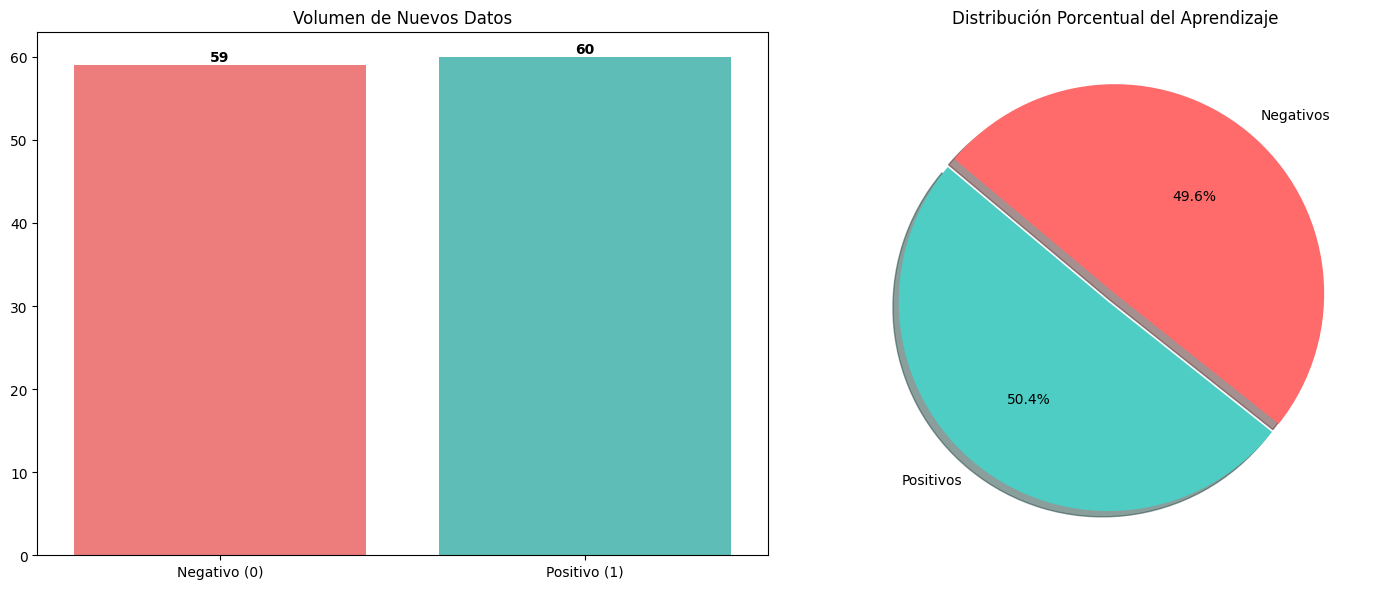


🔍 TOP 10 PALABRAS CLAVE (INFLUENCIA ACTUAL):

🟢 MÁS POSITIVAS:                🔴 MÁS NEGATIVAS:
muy: 4.008                     no: -7.081
excelente: 3.787               mal: -3.368
centro: 2.528                  ni: -2.944
todo: 2.484                    lo: -2.285
duda: 2.353                    peor: -2.157
gracias: 2.238                 mala: -2.139
limpio: 2.168                  nada: -1.755
muy bien: 2.153                estrellas: -1.748
catedral: 2.137                era: -1.698
recomendable: 2.134            poco: -1.689

📝 ÚLTIMOS REGISTROS PROCESADOS:


,clean_text,y,fecha_recoleccion
114,"Pésimo servicio, hotel en decadencia. Comida e...",0,2025-12-28 06:46:34.091936
115,"Pésima experiencia\nSoy cliente habitual, gene...",0,2025-12-28 06:47:12.697015
116,"Excelente, rquisimo y abundante.\ndic 2025 • P...",1,2025-12-28 06:48:30.491898
117,Excelente todo!\nVinimos por unos happy hours ...,1,2025-12-28 06:48:45.091015
118,"La comida muy rica, la atención excelente, nos...",1,2025-12-28 06:48:59.191640


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

def monitorear_progreso():
    # Usamos la ruta definida en tu script principal
    if os.path.exists(DATASET_FEEDBACK):
        df_new = pd.read_csv(DATASET_FEEDBACK)

        # --- LIMPIEZA VISUAL ---
        print(f"📊 PANEL DE CONTROL DE INTELIGENCIA")
        print(f"------------------------------------")
        total = len(df_new)
        conteos = df_new['y'].value_counts().to_dict()
        pos = conteos.get(1, 0)
        neg = conteos.get(0, 0)

        print(f"Total de datos recolectados (Individual + Masivo): {total}")
        print(f"✅ Sentimientos Positivos: {pos}")
        print(f"❌ Sentimientos Negativos: {neg}")

        # --- CREACIÓN DE GRÁFICOS ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # 1. Gráfico de Barras (Volumen)
        # Usamos colores corporativos: Verde para positivo, Rojo para negativo
        sns.barplot(x=['Negativo (0)', 'Positivo (1)'], y=[neg, pos],
                    palette=['#FF6B6B', '#4ECDC4'], ax=ax1)
        ax1.set_title("Volumen de Nuevos Datos")
        for i, v in enumerate([neg, pos]):
            ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

        # 2. Gráfico Circular (Balance de la IA)
        colores = ['#4ECDC4', '#FF6B6B']
        if total > 0:
            ax2.pie([pos, neg], labels=['Positivos', 'Negativos'], autopct='%1.1f%%',
                    startangle=140, colors=colores, explode=(0.05, 0), shadow=True)
            ax2.set_title("Distribución Porcentual del Aprendizaje")

        plt.tight_layout()
        plt.show()

        # --- ANÁLISIS DE PESOS (COEFICIENTES) ---
        # Esto te dice qué palabras están "ganando" peso tras las nuevas cargas
        print("\n🔍 TOP 10 PALABRAS CLAVE (INFLUENCIA ACTUAL):")
        try:
            feature_names = vectorizer.get_feature_names_out()
            coefficients = model.coef_[0]
            features_df = pd.DataFrame({'Palabra': feature_names, 'Peso': coefficients})

            top_pos = features_df.sort_values(by='Peso', ascending=False).head(10)
            top_neg = features_df.sort_values(by='Peso', ascending=True).head(10)

            print("\n🟢 MÁS POSITIVAS:                🔴 MÁS NEGATIVAS:")
            for i in range(len(top_pos)):
                p_pos = f"{top_pos.iloc[i]['Palabra']}: {top_pos.iloc[i]['Peso']:.3f}"
                p_neg = f"{top_neg.iloc[i]['Palabra']}: {top_neg.iloc[i]['Peso']:.3f}"
                print(f"{p_pos.ljust(30)} {p_neg}")
        except NameError:
            print("⚠️ Ejecuta primero la celda del modelo para ver las palabras influyentes.")

        print(f"\n📝 ÚLTIMOS REGISTROS PROCESADOS:")
        display(df_new.tail(5))
    else:
        print("⚠️ Aún no hay datos de feedback o cargas masivas registradas.")

# Ejecutar reporte
monitorear_progreso()